In [33]:
import matplotlib.pyplot as plt
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any, Dict, Callable

In [34]:
# Not required but improved the default layout of plots
import scienceplots
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

In [35]:
from PIL import Image

sample_numb_per_scan = 50
roughness_types = [10, 90]

im_data = {
    "mean": [],
    "std": [],
    "angle": [],
    "roughness" : []
}

for roughness in roughness_types:

    img_export_path = Path(f"orbit_render_imgs_mesh_0_{roughness}R")

    for img_name, angle in zip(
        [f"{str(i).zfill(4)}.png" for i in range(sample_numb_per_scan)],
        np.linspace(0, -180, sample_numb_per_scan),
    ):
        img_path = img_export_path / img_name
        if not img_path.exists():
            continue
        
        # Load image
        img = np.array(Image.open(img_path))

        # Compute statistics
        im_data["mean"].append(img.mean())
        im_data["std"].append(img.std())
        im_data["angle"].append(angle)
        im_data["roughness"].append(roughness / 100)

# Convert to Polars DataFrame
im_df = pl.DataFrame(im_data)

im_df

mean,std,angle,roughness
f64,f64,f64,f64
21.171768,62.327621,0.0,0.1
19.017975,56.325512,-3.673469,0.1
26.532578,62.877309,-7.346939,0.1
41.688507,74.483051,-11.020408,0.1
59.443588,83.126274,-14.693878,0.1
…,…,…,…
125.016861,87.023445,-165.306122,0.9
102.189087,91.688277,-168.979592,0.9
79.233322,90.636475,-172.653061,0.9


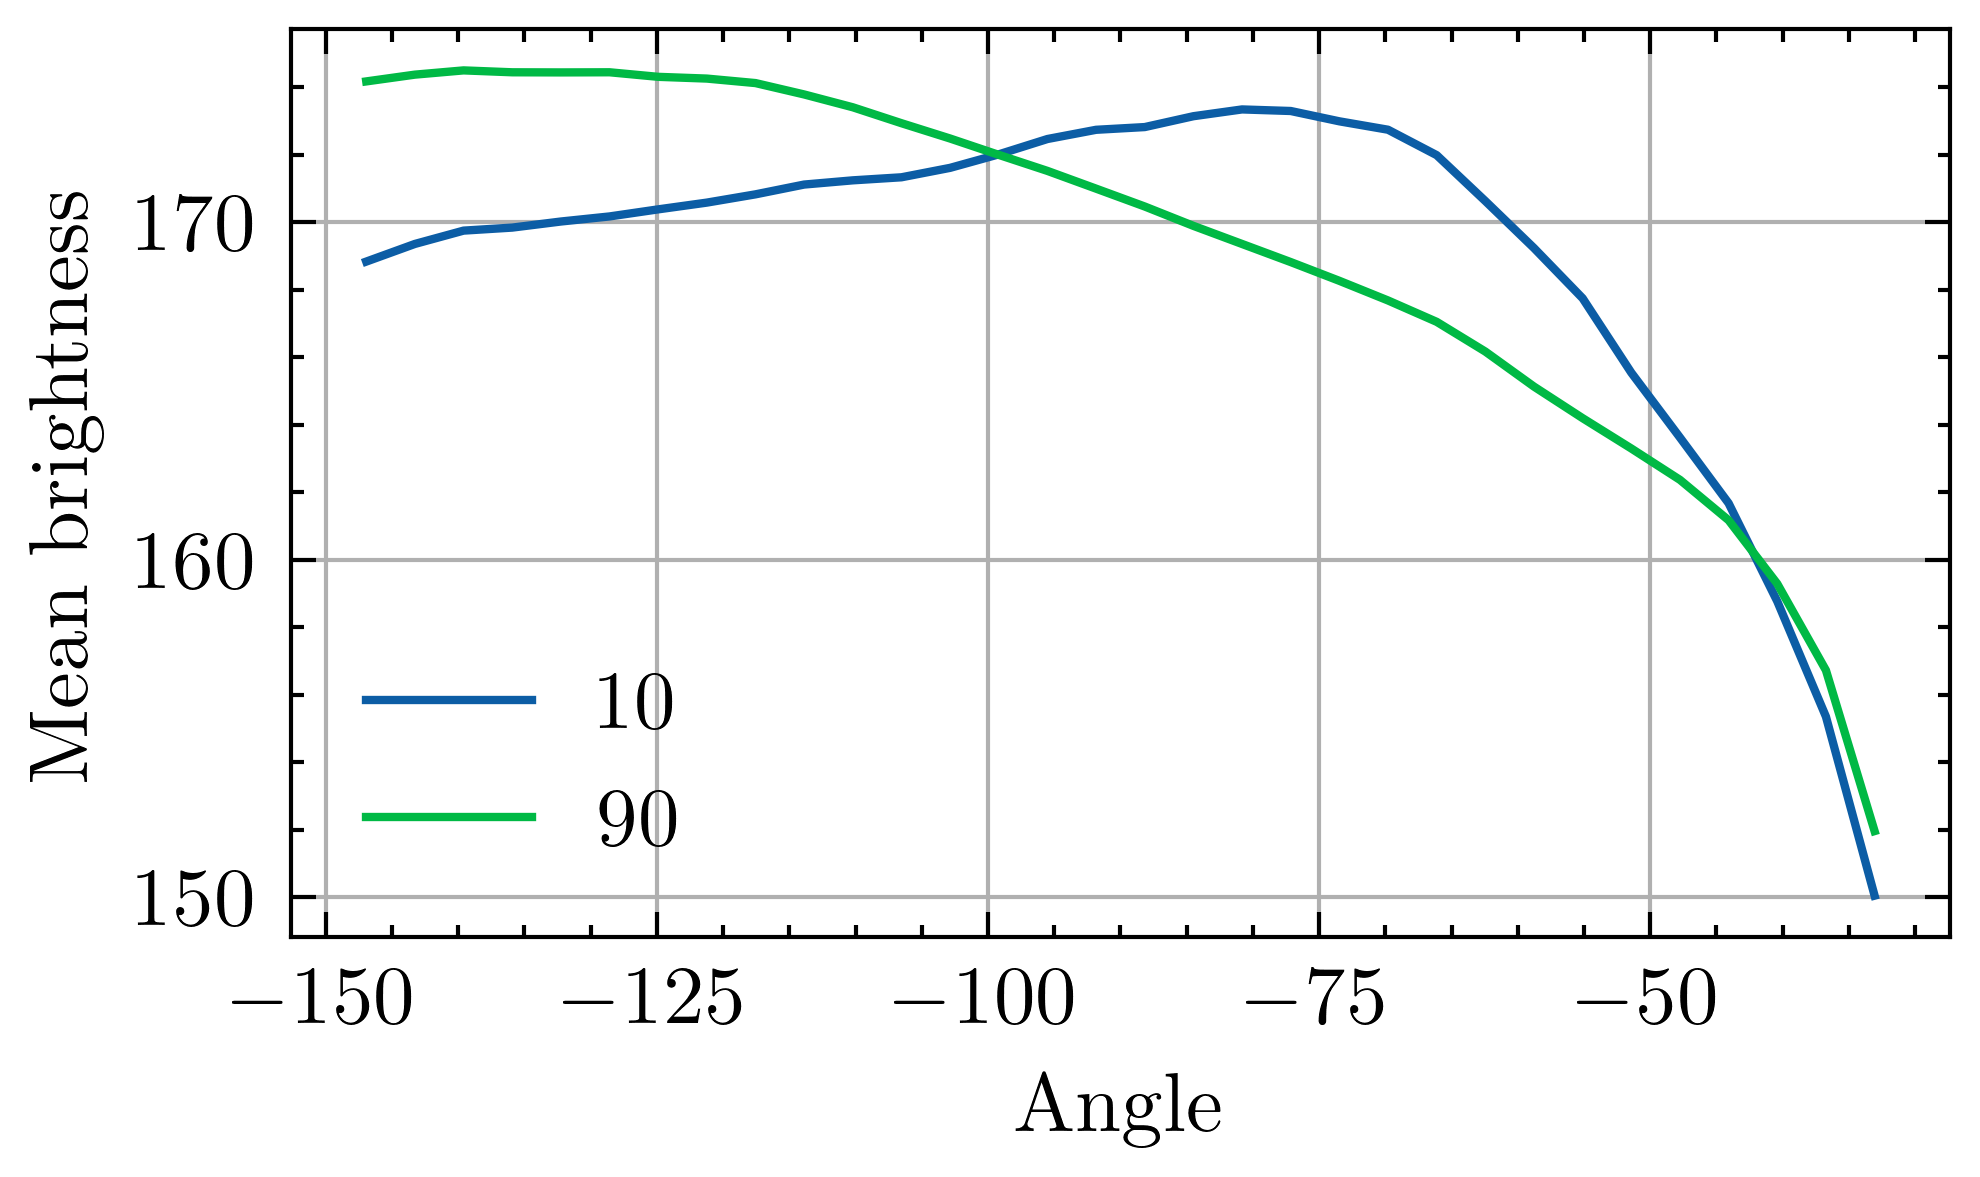

In [40]:
df_plot = im_df.filter(pl.col("angle") > -150, pl.col("angle") < -30)

for roughness_type in roughness_types:
    df_plot_roughness = df_plot.filter(pl.col("roughness") == roughness_type / 100)
    plt.plot(df_plot_roughness["angle"], df_plot_roughness["mean"], label = roughness_type)

plt.xlabel("Angle")
plt.ylabel("Mean brightness")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()